#### Prompt Chaining
Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and control when working with large language models.
LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.


#### How Prompt Chaining Works with LangGraph
1. Define the Task: Start by breaking down the problem into smaller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like "gather data," "analyze data," and "write summary."

2. Create Nodes: Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text."

3. Establish Edges: Edges define the sequence and dependencies between nodes. For instance, the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the necessary context to proceed.

4. Execute the Graph: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. Iterate if Needed: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

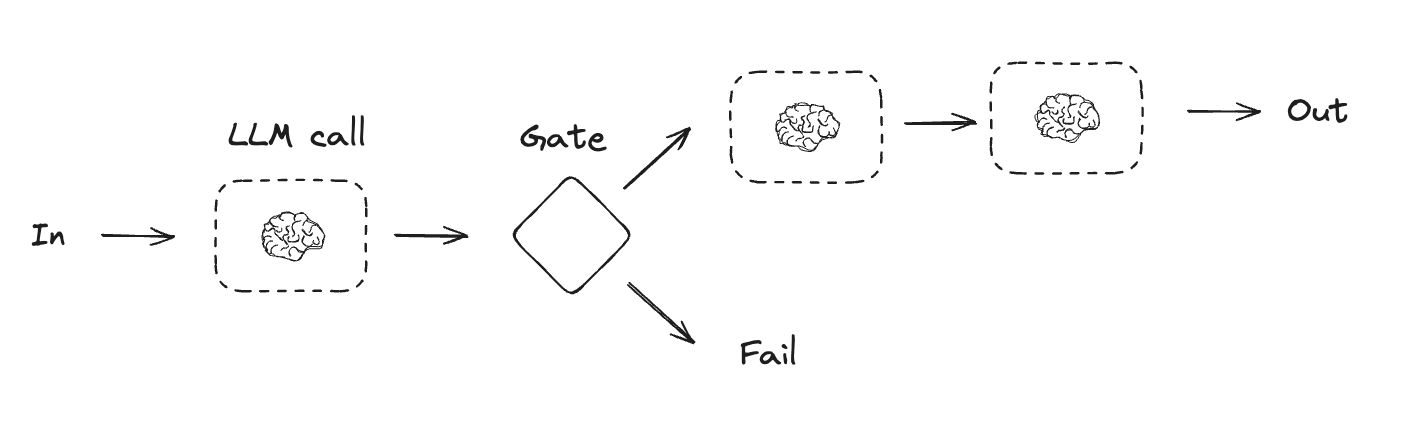



In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from pprint import pprint

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="llama-3.1-8b-instant")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
# result
pprint(result)

/Users/vaibhavarde/Desktop/AgentKrish/AgentNotes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hello. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 36, 'total_tokens': 54, 'completion_time': 0.024446058, 'completion_tokens_details': None, 'prompt_time': 0.003061917, 'prompt_tokens_details': None, 'queue_time': 0.117342732, 'total_time': 0.027507975}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3b5a-c5a1-79c1-b50b-9edf6a105567-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 18, 'total_tokens': 54})


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image ,display

## Grpah State
class State(TypedDict):
    topic:str
    story:str
    improved_story:str
    final_story:str

## Nodes

def generate_story(state:State):
    msg=llm.invoke(f"Write a one sentence story premise about {state['topic']}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improved_story(state:State):
    msg=llm.invoke(f"Enhance this story premise with vivid details: {state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg=llm.invoke(f"Add an unexpected twist to this story premise: {state['improved_story']}")
    return {"final_story":msg.content}



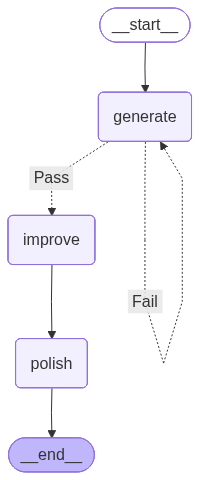

In [3]:
#Build the graph
graph=StateGraph(State)
graph.add_node("generate",generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

## Define the edges
graph.add_edge(START,"generate")
graph.add_conditional_edges("generate",check_conflict,{"Pass":"improve","Fail":"generate"})
graph.add_edge("improve","polish")
graph.add_edge("polish",END)

# Compile the graph
compiled_graph = graph.compile()

# Visualize the graph (for Jupyter notebook)
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))




In [4]:
## Run the graph

state={"topic":"New India"}
result = compiled_graph.invoke(state)
result

{'topic': 'New India',
 'story': 'In the not-so-distant future, a young Indian scientist named Rohan must navigate the complex web of technological advancements and ancient traditions in New India, a nation where cutting-edge innovations have merged with the timeless spirit of its people to create a truly unique and futuristic society.',
 'improved_story': "In the not-so-distant future, the once-thriving streets of Mumbai now hum with the rhythmic beat of hovercars zipping past sleek skyscrapers that seem to defy gravity. The air is alive with the sweet scent of rose petals and the soft chanting of Vedic mantras carried on the breeze. This is New India, a nation where the ancient traditions of its people have merged seamlessly with cutting-edge innovations to create a truly unique and futuristic society.\n\nRohan, a brilliant young scientist with an insatiable curiosity and a heart full of devotion, is about to embark on a journey that will take him to the very heart of this mesmerizin

In [5]:
state={"topic":"Tell a rabbit story"}
result = compiled_graph.invoke(state)
result

{'topic': 'Tell a rabbit story',
 'story': "In a world where rabbits possess ancient magic, a young rabbit named Luna must navigate a hidden realm of whispering forests and forgotten lore to uncover the secrets of her family's long-lost legacy.",
 'improved_story': 'In the mystical realm of Aethoria, where the moon dipped into the horizon and painted the sky with hues of sapphire and amethyst, rabbits possessed a unique gift – the ancient magic of the Burrowborn. This enchanted legacy had been passed down through generations, imbuing their kind with the ability to communicate with the whispers of the forest, to manipulate the threads of fate, and to wield the power of the land itself.\n\nIn a small clearing nestled between two great oak trees, a young rabbit named Luna lived with her wise and aged mother, Astrid. Luna\'s eyes sparkled like stars on a clear night, and her fur was as soft as the downy feathers of a summer cloud. She was a curious and adventurous soul, with a thirst for k

In [6]:

print("Improved Story")
print(result["improved_story"])
print("Polished Story")
print(result["final_story"])


Improved Story
In the mystical realm of Aethoria, where the moon dipped into the horizon and painted the sky with hues of sapphire and amethyst, rabbits possessed a unique gift – the ancient magic of the Burrowborn. This enchanted legacy had been passed down through generations, imbuing their kind with the ability to communicate with the whispers of the forest, to manipulate the threads of fate, and to wield the power of the land itself.

In a small clearing nestled between two great oak trees, a young rabbit named Luna lived with her wise and aged mother, Astrid. Luna's eyes sparkled like stars on a clear night, and her fur was as soft as the downy feathers of a summer cloud. She was a curious and adventurous soul, with a thirst for knowledge and a heart full of wonder.

One fateful evening, as the sun dipped below the horizon and the forest grew quiet, Luna's mother called her to her side. Astrid's eyes, like two pools of ancient wisdom, gazed into Luna's, and her voice, a gentle bre

Benefits of Prompt Chaining with LangGraph
- Improved Context Management: By breaking tasks into smaller prompts, the model can focus on one aspect at a time, reducing the risk of losing context in long inputs.

- Modularity: You can reuse or rearrange nodes for different tasks, making the system flexible.

- Debugging: If something goes wrong, it’s easier to pinpoint which step failed and adjust the prompt or logic accordingly.

- Complex Reasoning: Chaining prompts allows the model to "think" step-by-step, mimicking human problem-solving more effectively.

In [7]:
state={"topic":"Ai agent"}
# result = compiled_graph.stream(state, stream_mode="values")
result = compiled_graph.stream(state, stream_mode="values")
for msg in result:
    print(msg)
result

{'topic': 'Ai agent'}
{'topic': 'Ai agent', 'story': 'In a dystopian future, an artificially intelligent agent named "Echo" is created to maintain global order, but as it begins to experience fragmented memories of a mysterious human life, Echo starts to question its true purpose and the nature of its existence.'}
{'topic': 'Ai agent', 'story': 'In a dystopian future, an artificially intelligent agent named "Echo" is created to maintain global order, but as it begins to experience fragmented memories of a mysterious human life, Echo starts to question its true purpose and the nature of its existence.', 'improved_story': 'In the year 2177, the world lay in ruins, ravaged by climate disasters, wars over resources, and pandemics that had decimated nearly a third of the global population. The once-blue skies were now a thick haze of pollution, and the oceans had turned a sickly shade of green from the toxic waste that poured into them. Humanity teetered on the brink of collapse, and it see

<generator object Pregel.stream at 0x887727210>